In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/cleaned_data.csv')
log_cols = [c for c in df.columns if c.endswith('_log')]
analysis_cols = log_cols + ['behavior_score']

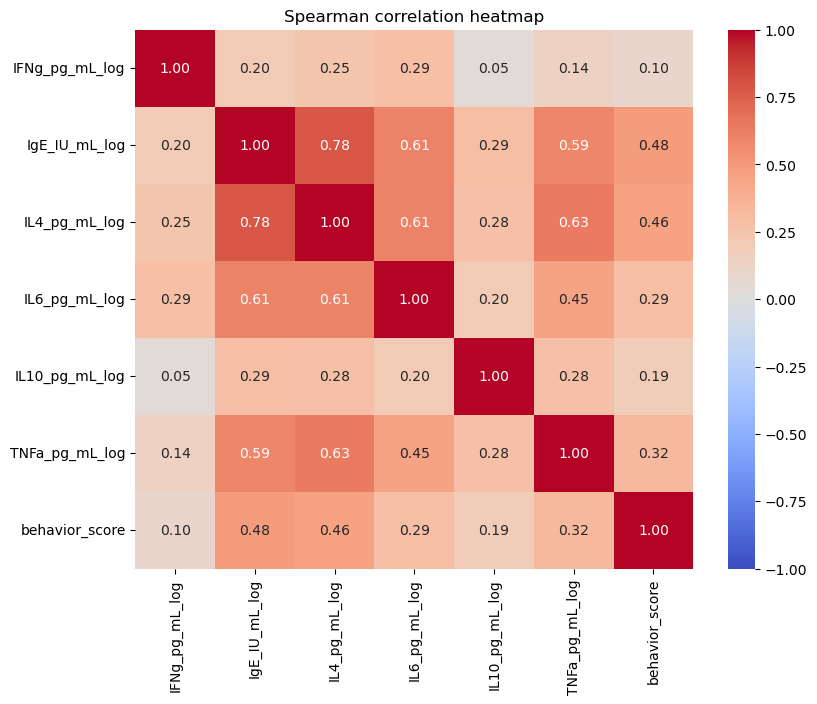

In [2]:
# WHY Spearman, not Pearson? Spearman measures monotonic relationships and is robust
# to the outliers/non-normal shapes common in biological data. Pearson assumes linear
# relationships between normally-distributed variables — riskier here even after log transform.
corr_matrix = df[analysis_cols].corr(method='spearman')

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Spearman correlation heatmap')
plt.show()

In [5]:
results = []
for i, col1 in enumerate(analysis_cols):
    for col2 in analysis_cols[i+1:]:
        rho, pval = stats.spearmanr(df[col1], df[col2])
        results.append({'var1': col1, 'var2': col2, 'rho': rho, 'p_value': pval})

results_df = pd.DataFrame(results)

In [6]:
reject, pvals_corrected, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['p_fdr'] = pvals_corrected
results_df['significant_after_fdr'] = reject

In [7]:
results_df.sort_values('rho', key=abs, ascending=False)

,var1,var2,rho,p_value,p_fdr,significant_after_fdr
6,IgE_IU_mL_log,IL4_pg_mL_log,0.783912,1.924233e-32,4.040889e-31,True
13,IL4_pg_mL_log,TNFa_pg_mL_log,0.634531,2.827682e-18,2.969066e-17,True
7,IgE_IU_mL_log,IL6_pg_mL_log,0.606911,1.835765e-16,1.163709e-15,True
11,IL4_pg_mL_log,IL6_pg_mL_log,0.605597,2.216588e-16,1.163709e-15,True
9,IgE_IU_mL_log,TNFa_pg_mL_log,0.593678,1.178767e-15,4.950823e-15,True
10,IgE_IU_mL_log,behavior_score,0.484676,3.283516e-10,1.149230e-09,True
14,IL4_pg_mL_log,behavior_score,0.456417,4.356646e-09,1.306994e-08,True
16,IL6_pg_mL_log,TNFa_pg_mL_log,0.447150,9.675547e-09,2.539831e-08,True
20,TNFa_pg_mL_log,behavior_score,0.324852,4.994427e-05,1.165366e-04,True
8,IgE_IU_mL_log,IL10_pg_mL_log,0.294285,2.568009e-04,5.392818e-04,True


In [18]:
import pingouin as pg

partial_results = []
for col in log_cols:
    res = pg.partial_corr(data=df, x=col, y='behavior_score', covar='age', method='spearman')
    partial_results.append({'variable': col, 'partial_r': res['r'].values[0], 'p_val': res['p_val'].values[0]})

pd.DataFrame(partial_results)

,variable,partial_r,p_val
0,IFNg_pg_mL_log,0.091335,2.679401e-01
1,IgE_IU_mL_log,0.487026,3.009607e-10
2,IL4_pg_mL_log,0.453761,6.179620e-09
3,IL6_pg_mL_log,0.297243,2.320287e-04
4,IL10_pg_mL_log,0.192815,1.847579e-02
5,TNFa_pg_mL_log,0.323843,5.605511e-05
